In [1]:
# 10.6 Q1 - Old Faithful Geyser Clustering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv('datasets/old_faithful.csv')
print("Shape:", df.shape)
print(df.head())
print()
print("kind distribution:")
print(df['kind'].value_counts())

Shape: (272, 3)
   duration  waiting   kind
0     3.600       79   long
1     1.800       54  short
2     3.333       74   long
3     2.283       62  short
4     4.533       85   long

kind distribution:
kind
long     172
short    100
Name: count, dtype: int64


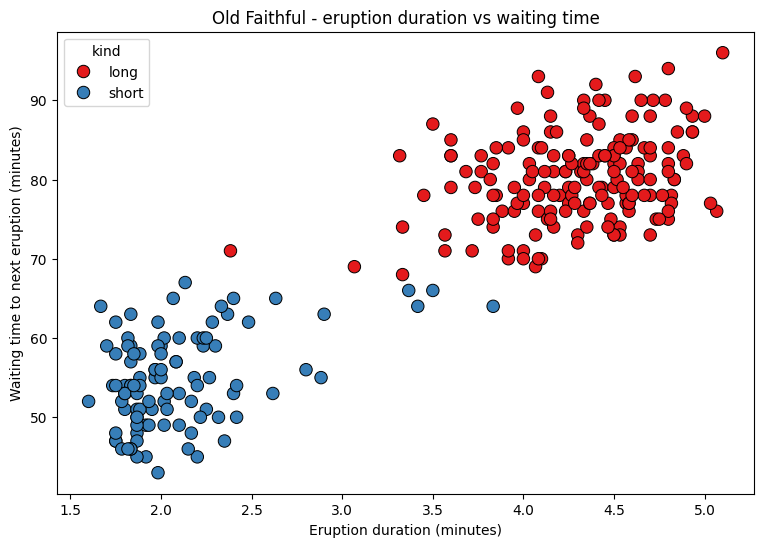

In [4]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='duration', y='waiting', hue='kind', data=df,
                palette='Set1', s=80, edgecolor='k')
plt.title('Old Faithful - eruption duration vs waiting time')
plt.xlabel('Eruption duration (minutes)')
plt.ylabel('Waiting time to next eruption (minutes)')
plt.show()

In [5]:
X = df[['duration', 'waiting']].values
sc = StandardScaler()
X_s = sc.fit_transform(X)
print("X shape:", X.shape)

X shape: (272, 2)


In [6]:
# Elbow Method

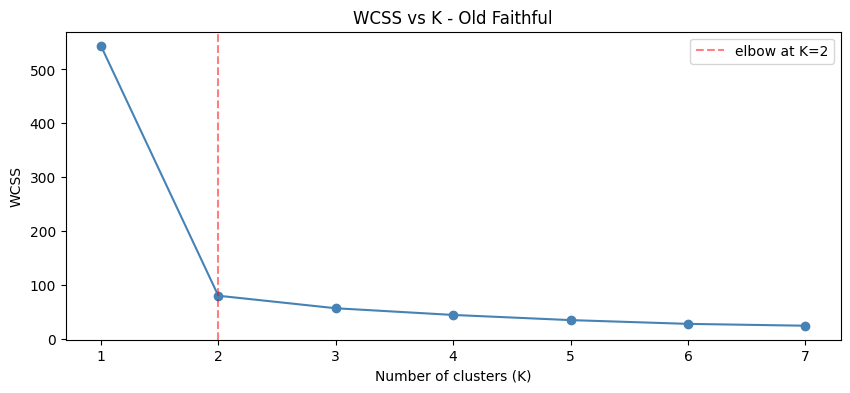

In [7]:
wcss = []
sil_scores = []
for k in range(1, 8):
    m = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    m.fit(X_s)
    wcss.append(m.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(X_s, m.labels_))
    else:
        sil_scores.append(np.nan)

plt.figure(figsize=(10, 4))
plt.plot(range(1, 8), wcss, 'o-', color='steelblue')
plt.axvline(2, color='red', linestyle='--', alpha=0.5, label='elbow at K=2')
plt.title('WCSS vs K - Old Faithful')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 8))
plt.legend()
plt.show()

In [8]:
# Train K-Means with K = 2

In [9]:
model = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
y_means = model.fit_predict(X_s)
df['cluster'] = y_means

centroids = sc.inverse_transform(model.cluster_centers_)
print("Centroids (original units):")
print(centroids)
print()
print("Silhouette score:", round(silhouette_score(X_s, y_means), 4))

Centroids (original units):
[[ 4.29632759 80.08045977]
 [ 2.05220408 54.59183673]]

Silhouette score: 0.7452


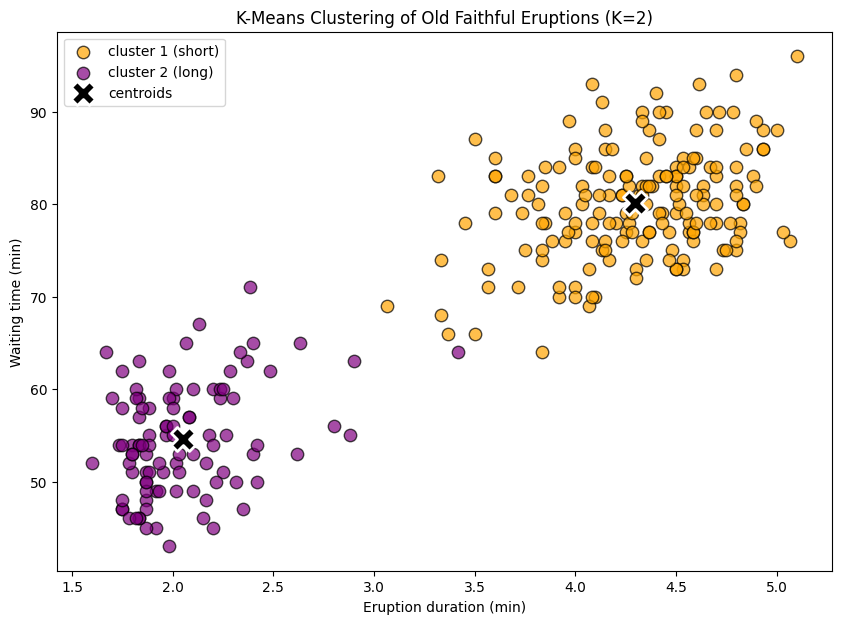

In [10]:
plt.figure(figsize=(10, 7))
plt.scatter(X[y_means==0, 0], X[y_means==0, 1], s=80, c='orange',
            label='cluster 1 (short)', edgecolors='k', alpha=0.7)
plt.scatter(X[y_means==1, 0], X[y_means==1, 1], s=80, c='purple',
            label='cluster 2 (long)', edgecolors='k', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black',
            marker='X', edgecolors='white', linewidths=2, label='centroids')
plt.xlabel('Eruption duration (min)')
plt.ylabel('Waiting time (min)')
plt.title('K-Means Clustering of Old Faithful Eruptions (K=2)')
plt.legend()
plt.show()

In [11]:
# Compare clusters with true 'kind' labels

In [12]:
ct = pd.crosstab(df['kind'], df['cluster'])
print("Cluster vs True kind:")
print(ct)
print()
print("K-Means reproduces the two natural clusters (long vs short) very well")

Cluster vs True kind:
cluster    0   1
kind            
long     171   1
short      3  97

K-Means reproduces the two natural clusters (long vs short) very well
